# House Price Prediction using Linear Regression

## SoftGrowTech Machine Learning Internship - Task 2

### Project Objective
The objective of this project is to build a Machine Learning model that predicts house prices based on various housing features using the Linear Regression algorithm.

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

### Machine Learning Algorithm
- Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:

housing = fetch_california_housing()


df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["HousePrice"] = housing.target


df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:

print("Dataset Shape:", df.shape)


df.info()

Dataset Shape: (20640, 9)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [5]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [7]:
print(df.columns)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'HousePrice'],
      dtype='str')


## Data Visualization

In this section, we visualize the dataset to understand feature distributions and relationships before training the machine learning model.

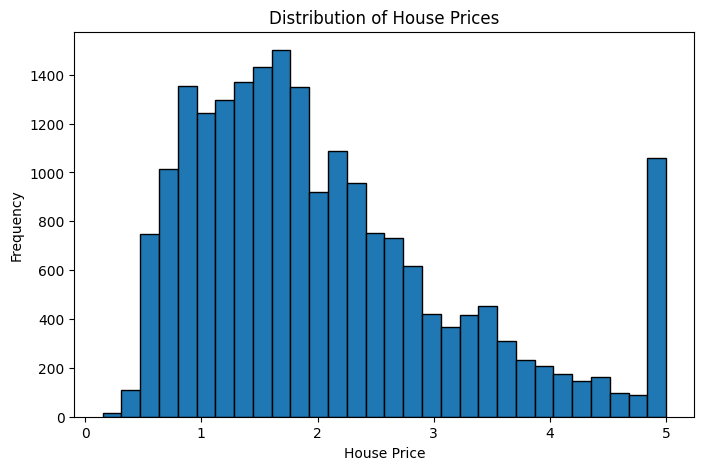

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["HousePrice"], bins=30, edgecolor="black")
plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.show()

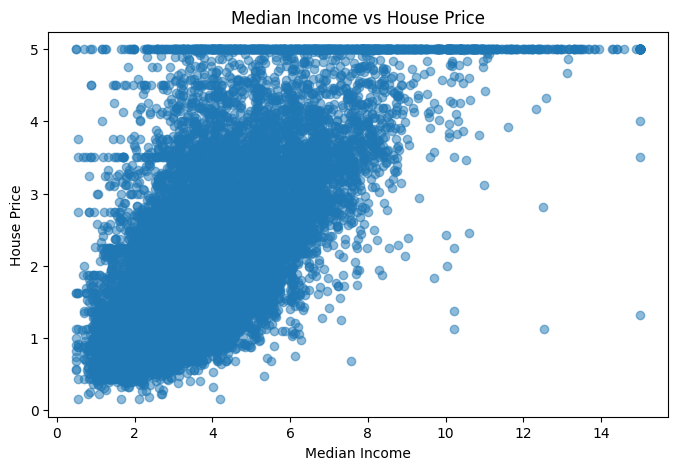

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(df["MedInc"], df["HousePrice"], alpha=0.5)
plt.title("Median Income vs House Price")
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.show()

In [10]:
correlation = df.corr()
correlation

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
HousePrice,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


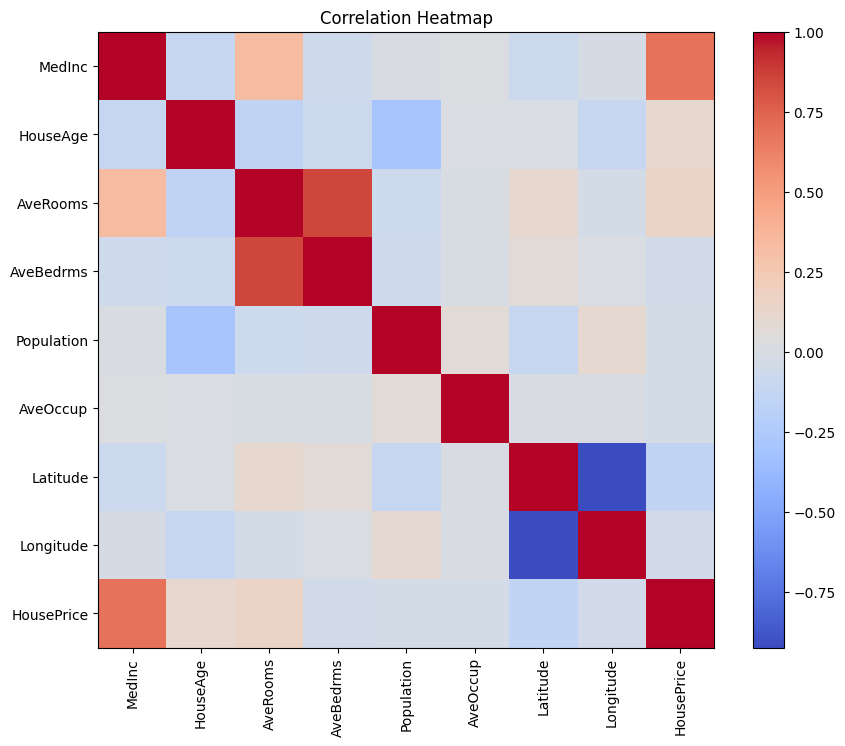

In [11]:
plt.figure(figsize=(10,8))

plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.show()

## Data Preparation

We separate the input features and target variable, then split the dataset into training and testing sets.

In [12]:

X = df.drop("HousePrice", axis=1)


y = df["HousePrice"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (20640, 8)
Target Shape: (20640,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (16512, 8)
Testing Data: (4128, 8)


## Model Training

We use the Linear Regression algorithm to train the model using the training dataset.

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## Model Prediction

The trained model is used to predict house prices for the testing dataset.

In [15]:
y_pred = model.predict(X_test)

predictions = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

predictions.head(10)

,Actual Price,Predicted Price
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


In [16]:
comparison = predictions.copy()
comparison["Difference"] = comparison["Actual Price"] - comparison["Predicted Price"]

comparison.head(10)

,Actual Price,Predicted Price,Difference
0,0.47700,0.719123,-0.242123
1,0.45800,1.764017,-1.306017
2,5.00001,2.709659,2.290351
3,2.18600,2.838926,-0.652926
4,2.78000,2.604657,0.175343
5,1.58700,2.011754,-0.424754
6,1.98200,2.645500,-0.663500
7,1.57500,2.168755,-0.593755
8,3.40000,2.740746,0.659254
9,4.46600,3.915615,0.550385


## Model Evaluation

The performance of the Linear Regression model is evaluated using different regression metrics.

In [17]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.5332
Mean Squared Error (MSE): 0.5559
Root Mean Squared Error (RMSE): 0.7456
R² Score: 0.5758


## Actual vs Predicted House Prices

This graph compares the actual house prices with the values predicted by the Linear Regression model.

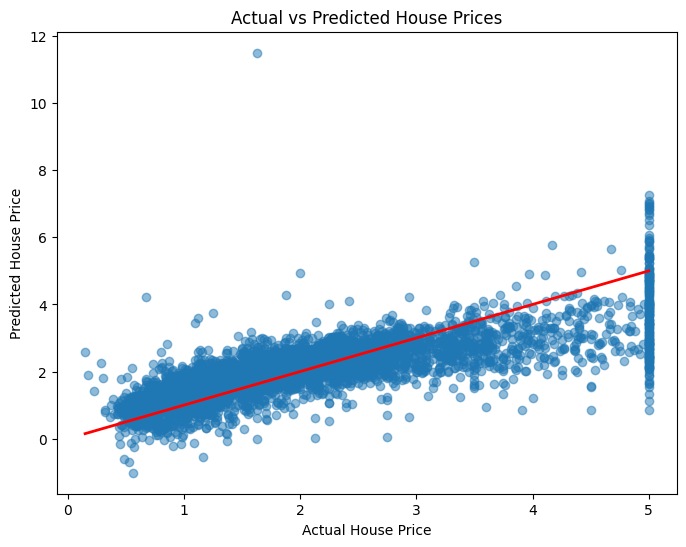

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.show()

## Feature Importance

The coefficients of the Linear Regression model indicate how each feature influences house prices.

In [19]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


## Custom House Price Prediction

Predict the price of a house using custom input values.

In [20]:
sample_house = pd.DataFrame([{
    "MedInc": 8.0,
    "HouseAge": 25,
    "AveRooms": 6.5,
    "AveBedrms": 1.0,
    "Population": 1200,
    "AveOccup": 3.0,
    "Latitude": 34.05,
    "Longitude": -118.25
}])

predicted_price = model.predict(sample_house)

print(f"Predicted House Price: {predicted_price[0]:.3f}")

Predicted House Price: 3.770


# Conclusion

This project successfully developed a House Price Prediction model using the Linear Regression algorithm.

### Key Achievements
- Loaded and explored the California Housing dataset.
- Performed data preprocessing and validation.
- Visualized important patterns in the dataset.
- Trained a Linear Regression model.
- Predicted house prices for unseen data.
- Evaluated the model using MAE, MSE, RMSE, and R² Score.

The project demonstrates the complete workflow of a supervised machine learning regression task and satisfies the requirements of the SoftGrowTech Machine Learning Internship Task 2.

In [21]:
import pickle

# Save the trained model
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully as model.pkl")

Model saved successfully as model.pkl
